Accuracy: 0.94
Precision: 0.972972972972973
Recall: 0.9113924050632911


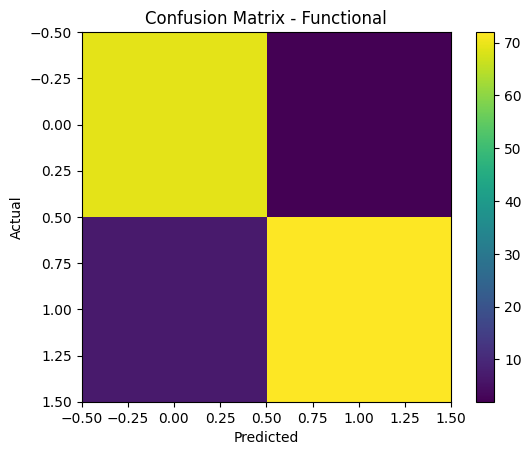

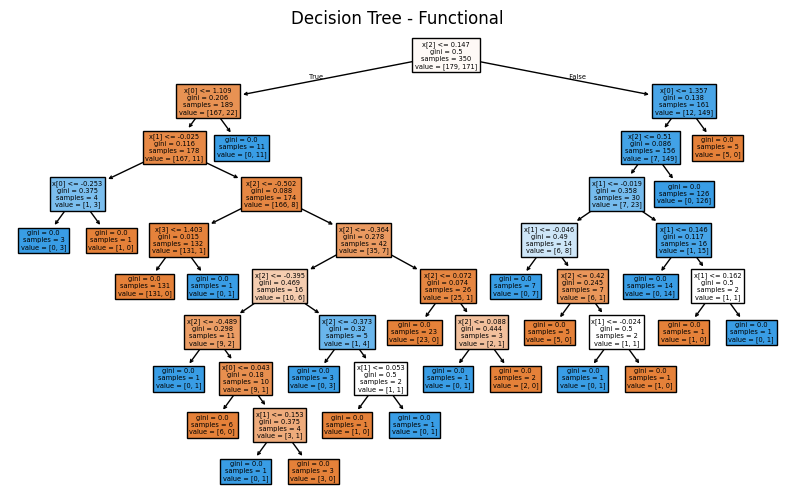

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

X, y = make_classification(n_samples=500, n_features=4, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix - Functional")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

plt.figure(figsize=(10,6))
plot_tree(model, filled=True)
plt.title("Decision Tree - Functional")
plt.show()

Accuracy: 0.9


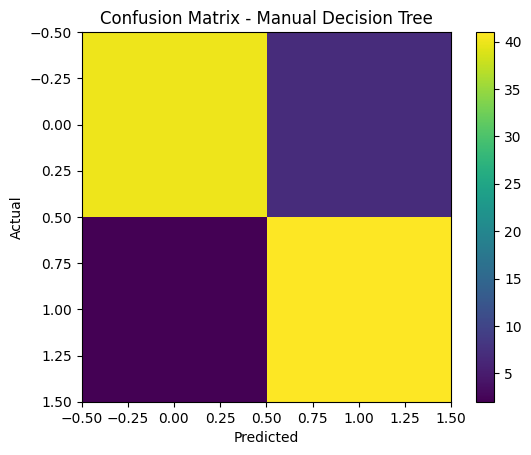

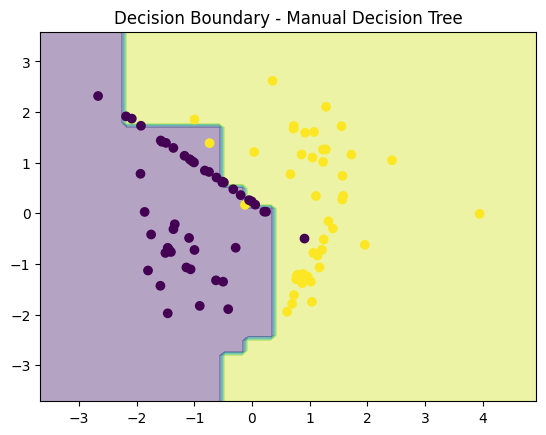

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X, y = make_classification(
    n_samples=300,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_repeated=0,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

def gini(y):
    counts = Counter(y)
    impurity = 1
    for count in counts.values():
        p = count / len(y)
        impurity -= p**2
    return impurity

def best_split(X, y):
    best_gini = 1
    best_feature = None
    best_threshold = None
    for feature in range(X.shape[1]):
        thresholds = np.unique(X[:, feature])
        for threshold in thresholds:
            left_mask = X[:, feature] <= threshold
            right_mask = X[:, feature] > threshold
            if sum(left_mask) == 0 or sum(right_mask) == 0:
                continue
            left_gini = gini(y[left_mask])
            right_gini = gini(y[right_mask])
            weighted_gini = (len(y[left_mask])/len(y))*left_gini + \
                            (len(y[right_mask])/len(y))*right_gini
            if weighted_gini < best_gini:
                best_gini = weighted_gini
                best_feature = feature
                best_threshold = threshold
    return best_feature, best_threshold

class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

def build_tree(X, y, depth=0, max_depth=4):
    if len(set(y)) == 1 or depth == max_depth:
        return Node(value=Counter(y).most_common(1)[0][0])
    feature, threshold = best_split(X, y)
    if feature is None:
        return Node(value=Counter(y).most_common(1)[0][0])
    left_mask = X[:, feature] <= threshold
    right_mask = X[:, feature] > threshold
    left_child = build_tree(X[left_mask], y[left_mask], depth+1, max_depth)
    right_child = build_tree(X[right_mask], y[right_mask], depth+1, max_depth)
    return Node(feature, threshold, left_child, right_child)

def predict(node, x):
    if node.value is not None:
        return node.value
    if x[node.feature] <= node.threshold:
        return predict(node.left, x)
    else:
        return predict(node.right, x)

tree = build_tree(X_train, y_train)

y_pred = np.array([predict(tree, x) for x in X_test])

TP = sum((y_pred == 1) & (y_test == 1))
TN = sum((y_pred == 0) & (y_test == 0))
FP = sum((y_pred == 1) & (y_test == 0))
FN = sum((y_pred == 0) & (y_test == 1))

accuracy = (TP + TN) / (TP + TN + FP + FN)

print("Accuracy:", accuracy)

cm = np.array([[TN, FP],[FN, TP]])

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix - Manual Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

grid = np.c_[xx.ravel(), yy.ravel()]
Z = np.array([predict(tree, point) for point in grid])
Z = Z.reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, Z, alpha=0.4)
plt.scatter(X_test[:,0], X_test[:,1], c=y_test)
plt.title("Decision Boundary - Manual Decision Tree")
plt.show()